In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
df.shape

(59598, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [ ]:
df.isnull().sum()

,0
Employee ID,0
Age,0
Gender,0
Years at Company,0
Job Role,0
Monthly Income,0
Work-Life Balance,0
Job Satisfaction,0
Performance Rating,0
Number of Promotions,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
Stayed,31260
Left,28338


In [ ]:
df['Attrition'].value_counts(normalize = True) * 100

,proportion
Attrition,
Stayed,52.451425
Left,47.548575


In [ ]:
df.describe()

,Employee ID,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure
count,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000,59598.000000
mean,37227.118729,38.565875,15.753901,7302.397983,0.832578,50.007651,1.648075,55.758415
std,21519.150028,12.079673,11.245981,2151.457423,0.994991,28.466459,1.555689,25.411090
min,1.000000,18.000000,1.000000,1316.000000,0.000000,1.000000,0.000000,2.000000
25%,18580.250000,28.000000,7.000000,5658.000000,0.000000,25.000000,0.000000,36.000000
50%,37209.500000,39.000000,13.000000,7354.000000,1.000000,50.000000,1.000000,56.000000
75%,55876.750000,49.000000,23.000000,8880.000000,2.000000,75.000000,3.000000,76.000000
max,74498.000000,59.000000,51.000000,16149.000000,4.000000,99.000000,6.000000,128.000000


In [ ]:
df.nunique()

,0
Employee ID,59598
Age,42
Gender,2
Years at Company,51
Job Role,5
Monthly Income,9569
Work-Life Balance,4
Job Satisfaction,4
Performance Rating,4
Number of Promotions,5


In [ ]:
categorical_col = df.select_dtypes(include = 'object').columns
for col in categorical_col:
  print(f'\n{col}')
  print(df[col].unique())


Gender
['Male' 'Female']

Job Role
['Education' 'Media' 'Healthcare' 'Technology' 'Finance']

Work-Life Balance
['Excellent' 'Poor' 'Good' 'Fair']

Job Satisfaction
['Medium' 'High' 'Very High' 'Low']

Performance Rating
['Average' 'Low' 'High' 'Below Average']

Overtime
['No' 'Yes']

Education Level
['Associate Degree' 'Master’s Degree' 'Bachelor’s Degree' 'High School'
 'PhD']

Marital Status
['Married' 'Divorced' 'Single']

Job Level
['Mid' 'Senior' 'Entry']

Company Size
['Medium' 'Small' 'Large']

Remote Work
['No' 'Yes']

Leadership Opportunities
['No' 'Yes']

Innovation Opportunities
['No' 'Yes']

Company Reputation
['Excellent' 'Fair' 'Poor' 'Good']

Employee Recognition
['Medium' 'Low' 'High' 'Very High']

Attrition
['Stayed' 'Left']


In [ ]:
numerical_col = df.select_dtypes(include = 'number').columns
print(numerical_col)

Index(['Employee ID', 'Age', 'Years at Company', 'Monthly Income',
       'Number of Promotions', 'Distance from Home', 'Number of Dependents',
       'Company Tenure'],
      dtype='object')


# EDA (Exploratory Data Analysis)

# Target Variable Analysis

## Attrition

In [ ]:
df['Attrition'].value_counts() / len(df)* 100

,count
Attrition,
Stayed,52.451425
Left,47.548575


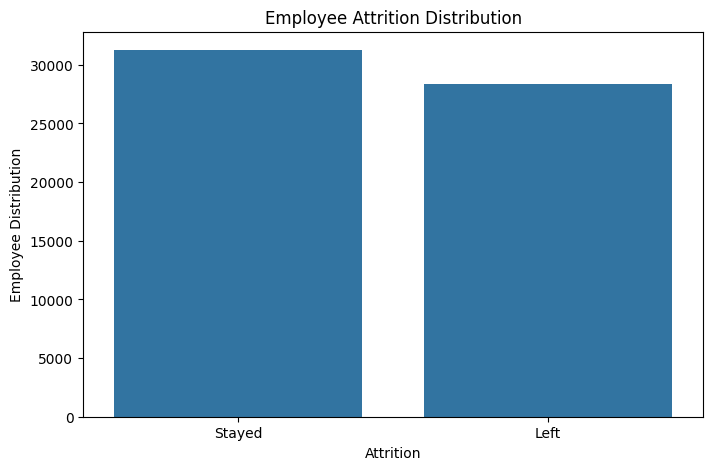

In [ ]:
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = 'Attrition')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition')
plt.ylabel('Employee Distribution')
plt.show()

### Business Insights:
- The target variable is reasonably balanced, with 52.45% employees staying and 47.54% employees leaving.

In [ ]:
df['Overtime'].value_counts()

,count
Overtime,
No,40148
Yes,19450


## Categorical Feature Analysis

In [ ]:
df.select_dtypes(include = 'object').columns

Index(['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Overtime', 'Education Level', 'Marital Status',
       'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition'],
      dtype='object')

## Gender vs Attrition

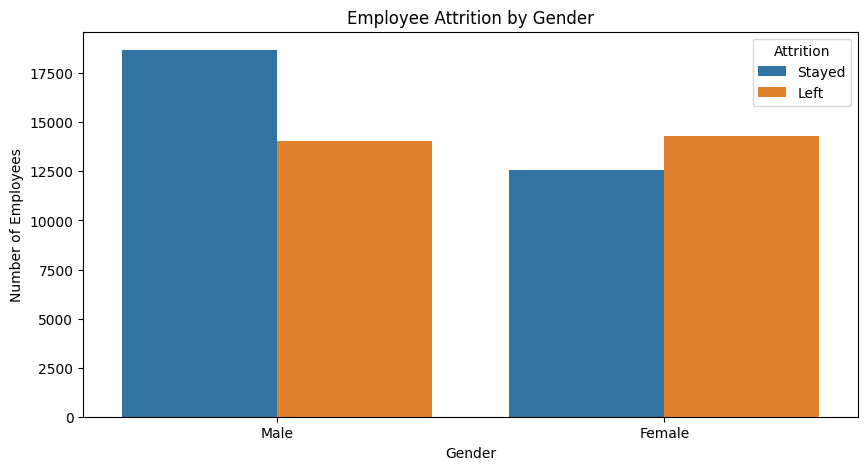

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Gender', hue = 'Attrition')
plt.title('Employee Attrition by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Gender'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Gender,,
Female,53.162813,46.837187
Male,42.942668,57.057332


### Business Insights:
- Gender shows a noticeable relationship with employee attrition. Female employees have a higher attrition rate (53.16%) compared with male employees (42.94%). This suggests that female employees are more likely to leave the organization in this dataset.

## Overtime vs Attrition

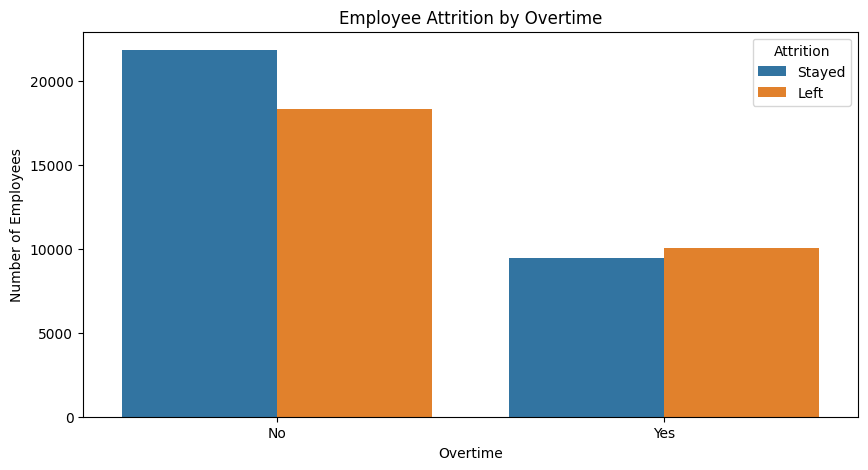

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Overtime', hue = 'Attrition')
plt.title('Employee Attrition by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Overtime'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Overtime,,
No,45.613729,54.386271
Yes,51.542416,48.457584


### Business Insights:
- Employees working overtime show a higher proportion of attrition than employees who do not work overtime.

## Job Role vs Attrition

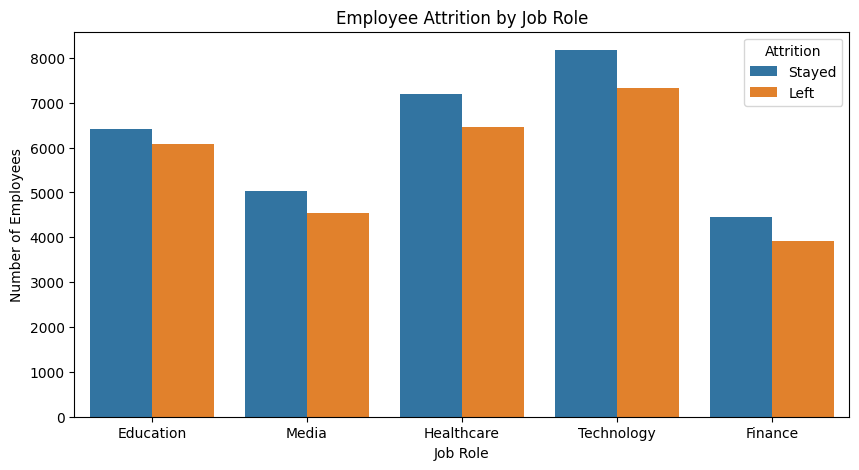

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Job Role', hue = 'Attrition')
plt.title('Employee Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Job Role'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Job Role,,
Education,48.718975,51.281025
Finance,46.797853,53.202147
Healthcare,47.309779,52.690221
Media,47.440986,52.559014
Technology,47.288321,52.711679


### Business Insights:
- Attrition proportions are relatively similar across job roles, ranging from 46.80% to 48.72%, suggesting only a small difference in attrition across these roles.

## Job Satisfaction vs Attrition

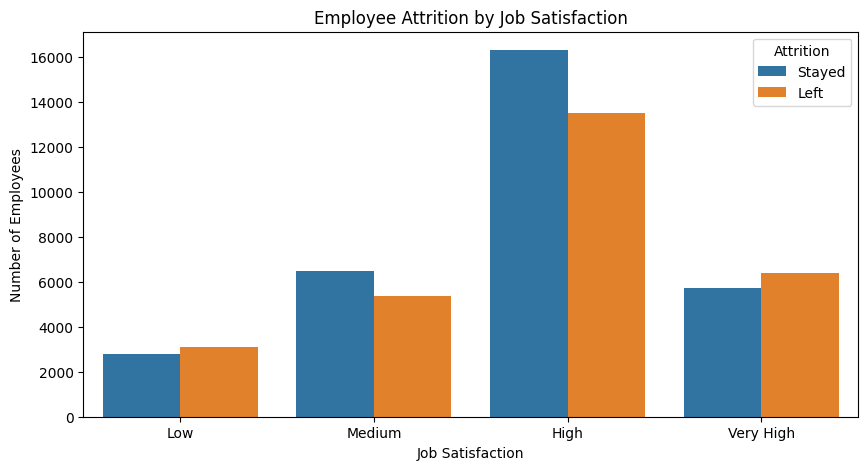

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Job Satisfaction', hue = 'Attrition', order = ['Low', 'Medium', 'High', 'Very High'])
plt.title('Employee Attrition by Job Satisfaction')
plt.xlabel('Job Satisfaction')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Job Satisfaction'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Job Satisfaction,,
High,45.297021,54.702979
Low,52.418944,47.581056
Medium,45.324532,54.675468
Very High,52.885806,47.114194


### Business Insights:
- Attrition varies across job satisfaction levels. The Very High satisfaction group has the highest attrition proportion (52.89%), while the Medium and High satisfaction groups have lower attrition proportions (around 45.3%). This suggests that job satisfaction alone does not show a straightforward relationship with attrition in this dataset.

## Work-Life Balance vs Attrition

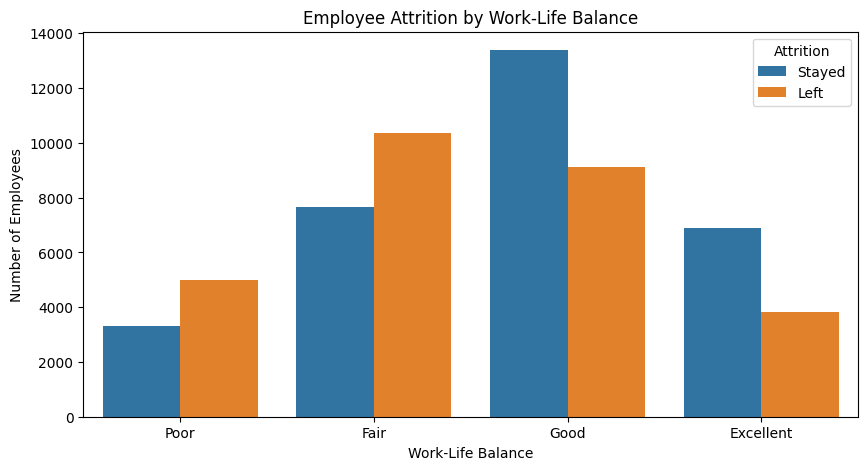

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'Work-Life Balance', hue = 'Attrition', order = ['Poor', 'Fair', 'Good', 'Excellent'])
plt.title('Employee Attrition by Work-Life Balance')
plt.xlabel('Work-Life Balance')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Work-Life Balance'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Work-Life Balance,,
Excellent,35.814908,64.185092
Fair,57.464258,42.535742
Good,40.558416,59.441584
Poor,60.108368,39.891632


### Business Insights:
- Employees with Poor work-life balance have the highest attrition proportion (60.10%), while employees with Excellent work-life balance have the lowest attrition proportion (35.81%). The results show a clear association between better work-life balance and lower employee attrition in this dataset.

## Performance Rating vs Attrition

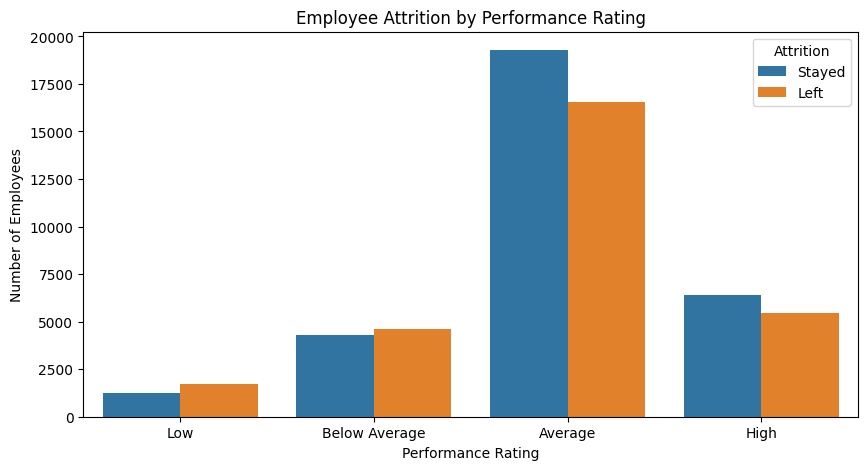

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Performance Rating', hue = 'Attrition', order = ['Low', 'Below Average', 'Average', 'High'])
plt.title('Employee Attrition by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Performance Rating'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Performance Rating,,
Average,46.151913,53.848087
Below Average,51.810056,48.189944
High,46.071669,53.928331
Low,57.525424,42.474576


### Business Insights:
- Employees with Low performance ratings have the highest attrition proportion (57.52%), while employees with Average and High performance ratings have lower attrition proportions (46.15% and 46.07%). This indicates an association between performance rating and employee attrition in the dataset.

## Education Level vs Attrition

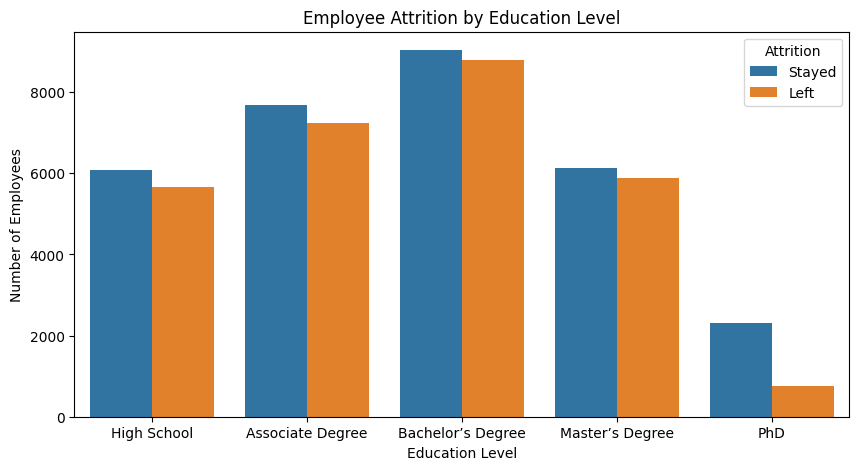

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Education Level', hue = 'Attrition', order = ['High School', 'Associate Degree', "Bachelor’s Degree", "Master’s Degree", 'PhD'])
plt.title('Employee Attrition by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Education Level'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Education Level,,
Associate Degree,48.474690,51.525310
Bachelor’s Degree,49.315606,50.684394
High School,48.246510,51.753490
Master’s Degree,48.926789,51.073211
PhD,24.862415,75.137585


### Business Insights:
- Employees with a PhD have an attrition proportion of only 24.86%, compared with approximately 48–49% for the other education levels.

## Marital Status vs Attrition

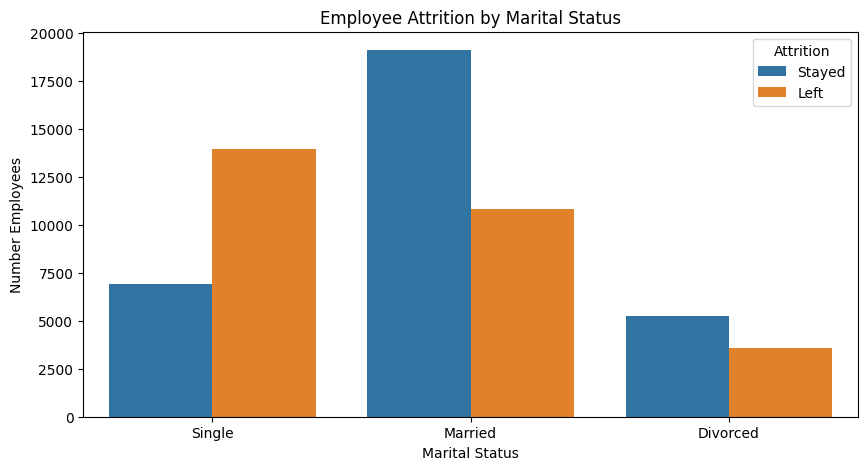

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Marital Status', hue = 'Attrition', order = ['Single', 'Married', 'Divorced'])
plt.title('Employee Attrition by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Marital Status'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Marital Status,,
Divorced,40.700169,59.299831
Married,36.147519,63.852481
Single,66.825054,33.174946


### Business Insights:
- Single employees: 66.82% left → highest attrition
- Divorced employees: 40.70% left
- Married employees: 36.14% left → lowest attrition

So, Single employees show substantially higher attrition than Married or Divorced employees in this dataset.

## Job Level vs Attrition

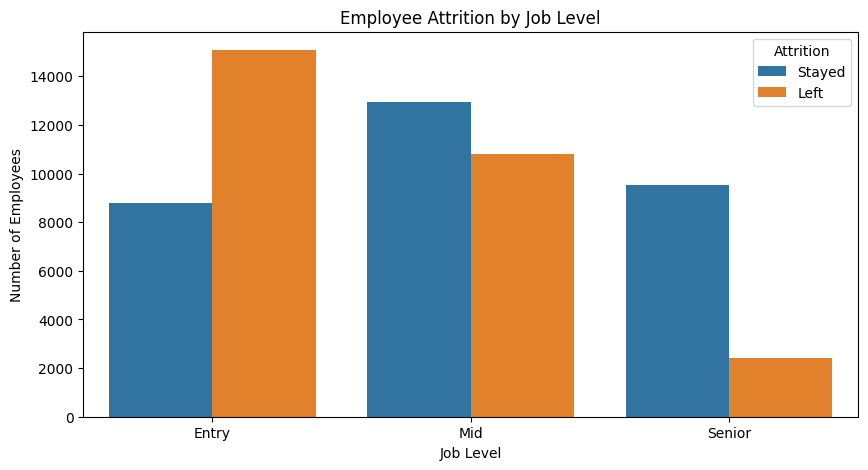

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'Job Level', hue = 'Attrition', order = ['Entry', 'Mid', 'Senior'])
plt.title('Employee Attrition by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Job Level'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Job Level,,
Entry,63.191855,36.808145
Mid,45.564771,54.435229
Senior,20.312239,79.687761


### Business Insights:
- Entry-level employees have the highest attrition — 63.19% left.
- Mid-level employees have moderate attrition — 45.56% left.
- Senior employees have the lowest attrition — only 20.31% left.

This suggests that attrition decreases as job level increases in this dataset.

## Company Size vs Attrition

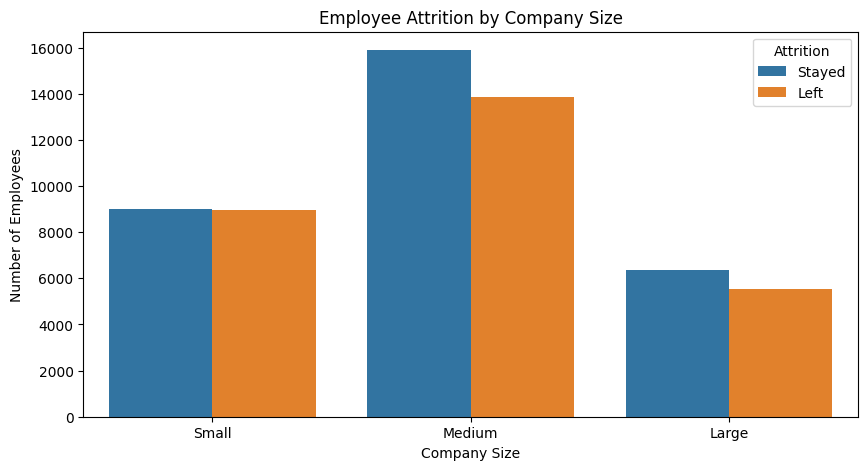

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'Company Size', hue = 'Attrition', order = ['Small', 'Medium', 'Large'])
plt.title('Employee Attrition by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Company Size'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Company Size,,
Large,46.467528,53.532472
Medium,46.579257,53.420743
Small,49.874547,50.125453


### Business Insights:
- Small companies have the highest attrition: 49.87%.
- Medium and Large companies are almost identical, around 46.5% attrition.

The difference is relatively small, so Company Size does not appear to be a very strong differentiating factor compared with variables such as Job Level or Work-Life Balance.

## Remote Work vs Attrition

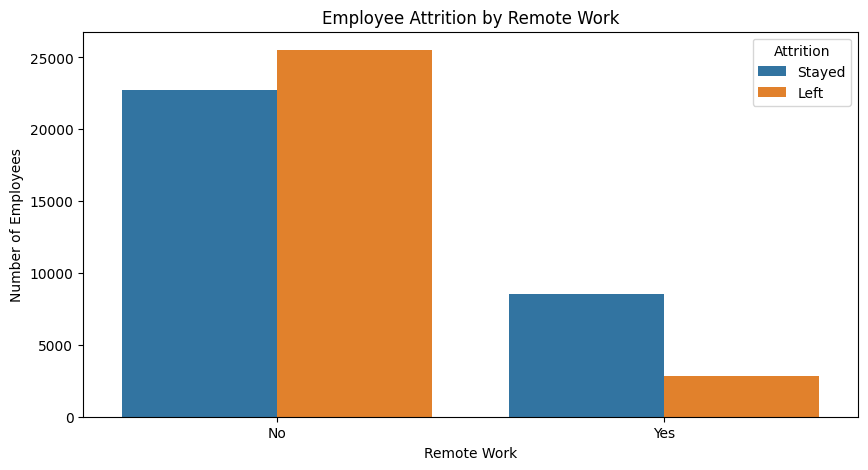

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Remote Work', hue = 'Attrition')
plt.title('Employee Attrition by Remote Work')
plt.xlabel('Remote Work')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Remote Work'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Remote Work,,
No,52.890814,47.109186
Yes,24.861343,75.138657


### Business Insights:
- Employees not working remotely have a much higher attrition rate: 52.89%.
- Employees working remotely have a lower attrition rate: 24.86%.

Therefore, Remote Work appears to have a strong relationship with attrition in this dataset.
The difference is approximately 28 percentage points.

## Leadership Opportunities vs Attrition

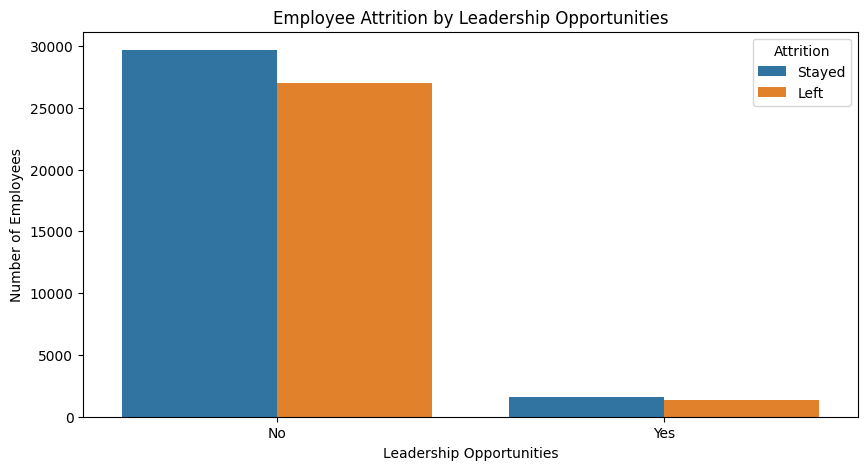

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Leadership Opportunities', hue = 'Attrition')
plt.title('Employee Attrition by Leadership Opportunities')
plt.xlabel('Leadership Opportunities')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Leadership Opportunities'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Leadership Opportunities,,
No,47.664079,52.335921
Yes,45.305003,54.694997


### Business Insights:
- Employees without leadership opportunities have an attrition rate of 47.66%.
- Employees with leadership opportunities have an attrition rate of 45.30%.
- The difference is only about 2.36 percentage points.

Therefore, Leadership Opportunities does not appear to have a very strong relationship with attrition compared with variables such as Work-Life Balance, Job Level, Marital Status, and Remote Work in the analysis.

## Innovation Opportunities vs Attrition

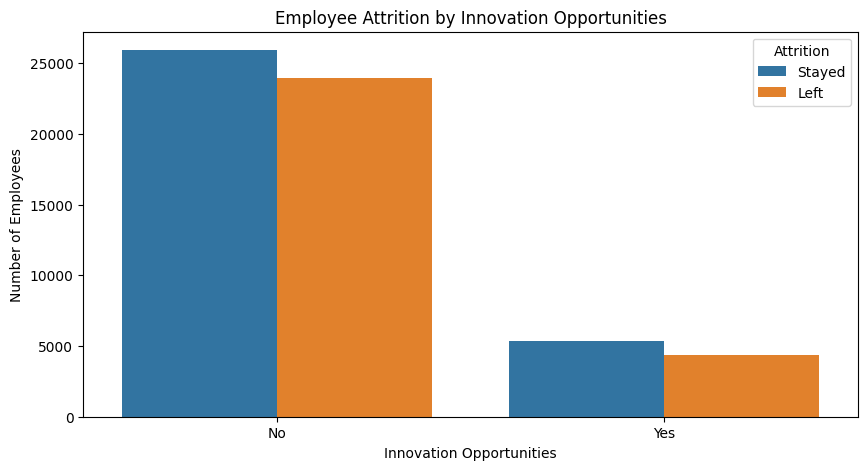

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Innovation Opportunities', hue = 'Attrition')
plt.title('Employee Attrition by Innovation Opportunities')
plt.xlabel('Innovation Opportunities')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Innovation Opportunities'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Innovation Opportunities,,
No,48.022848,51.977152
Yes,45.109760,54.890240


### Business Insights:
- Employees without innovation opportunities have an attrition rate of 48.02%.
- Employees with innovation opportunities have an attrition rate of 45.11%.
- The difference is approximately 2.91 percentage points.

So, in this dataset, Innovation Opportunities shows only a relatively small relationship with attrition.

## Company Reputation vs Attrition

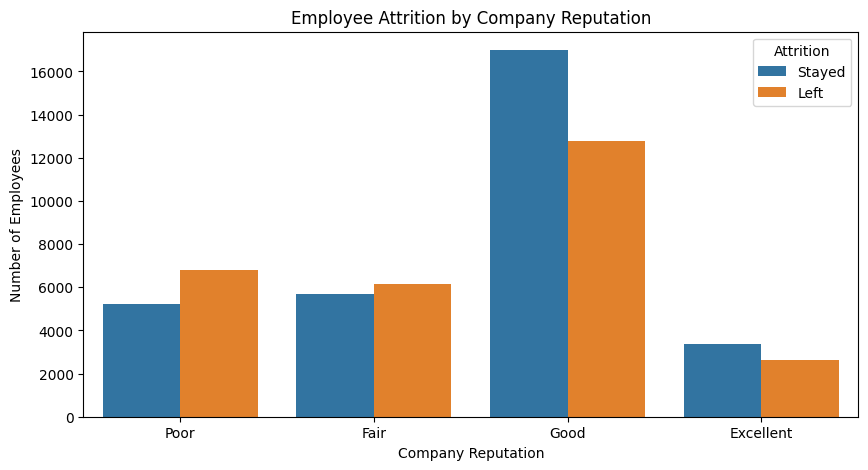

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Company Reputation', hue = 'Attrition', order = ['Poor', 'Fair', 'Good', 'Excellent'])
plt.title('Employee Attrition by Company Reputation')
plt.xlabel('Company Reputation')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Company Reputation'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Company Reputation,,
Excellent,43.922421,56.077579
Fair,51.942117,48.057883
Good,42.914735,57.085265
Poor,56.498255,43.501745


### Business Insights:
- Employees associated with companies having Poor or Fair reputation show higher attrition, while Good or Excellent reputation show lower attrition.

## Employee Recognition vs Attrition

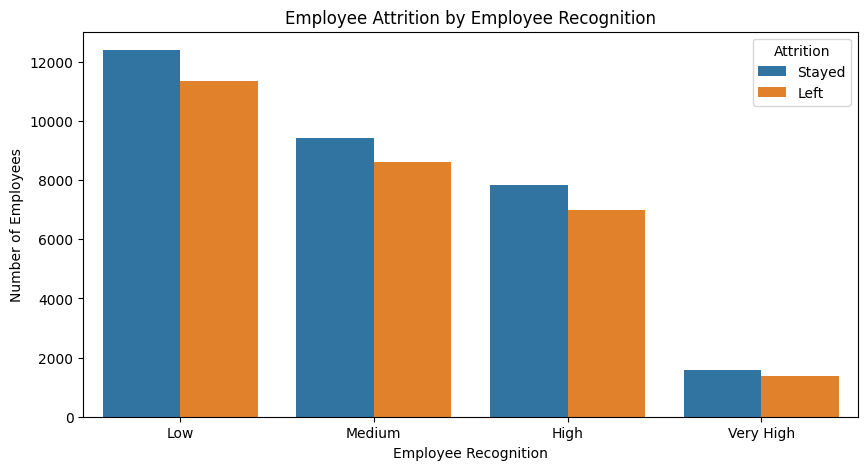

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'Employee Recognition', hue = 'Attrition', order = ['Low', 'Medium', 'High', 'Very High'])
plt.title('Employee Attrition by Employee Recognition')
plt.xlabel('Employee Recognition')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
pd.crosstab(
    df['Employee Recognition'],
    df['Attrition'],
    normalize = 'index'
) * 100

Attrition,Left,Stayed
Employee Recognition,,
High,47.184047,52.815953
Low,47.828100,52.171900
Medium,47.712527,52.287473
Very High,46.135673,53.864327


### Business Insights:
- Employee Recognition does not show a strong relationship with employee attrition in this dataset. Employees with very high recognition have slightly lower attrition (46.13%), but the difference is small.

# Numerical Feature Analysis

In [ ]:
df.select_dtypes(include='number').columns

Index(['Employee ID', 'Age', 'Years at Company', 'Monthly Income',
       'Number of Promotions', 'Distance from Home', 'Number of Dependents',
       'Company Tenure'],
      dtype='object')

## Age vs Attrition Distribution using Box Plot

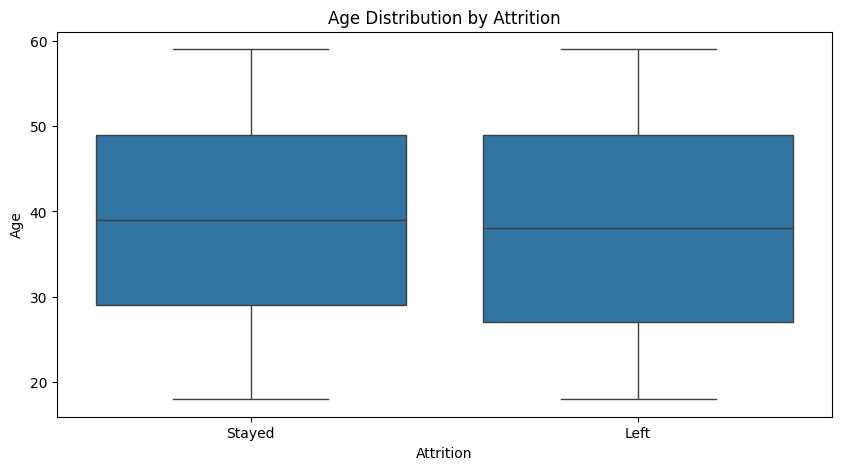

In [ ]:
plt.figure (figsize = (10,5))
sns.boxplot(data = df, x = 'Attrition', y = 'Age')
plt.title('Age Distribution by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Age')
plt.show()

## Age Distribution

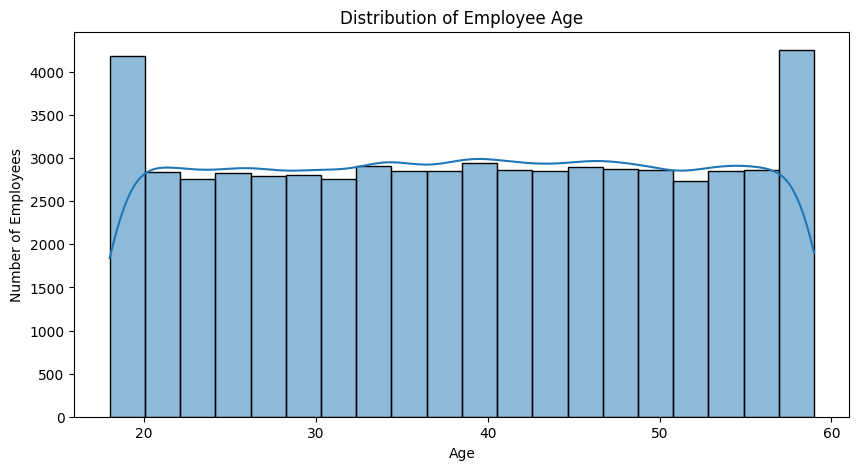

In [ ]:
plt.figure(figsize = (10,5))
sns.histplot(data = df, x = 'Age', bins = 20, kde = True)
plt.title('Distribution of Employee Age')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
df.groupby('Attrition')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,37.945480,12.257297,18.0,27.0,38.0,49.0,59.0
Stayed,31260.0,39.128279,11.888616,18.0,29.0,39.0,49.0,59.0


### Business Insights:
- The age of employees ranges from 18 to 59 years. The average age is approximately 39.12 years for employees who stayed and 37.94 years for employees who left. The age distributions of both groups are similar, although employees who left are slightly younger on average. The overall age distribution is relatively uniform, with no obvious extreme outliers.

## Year at Company vs Attrition Distribution using Box Plot

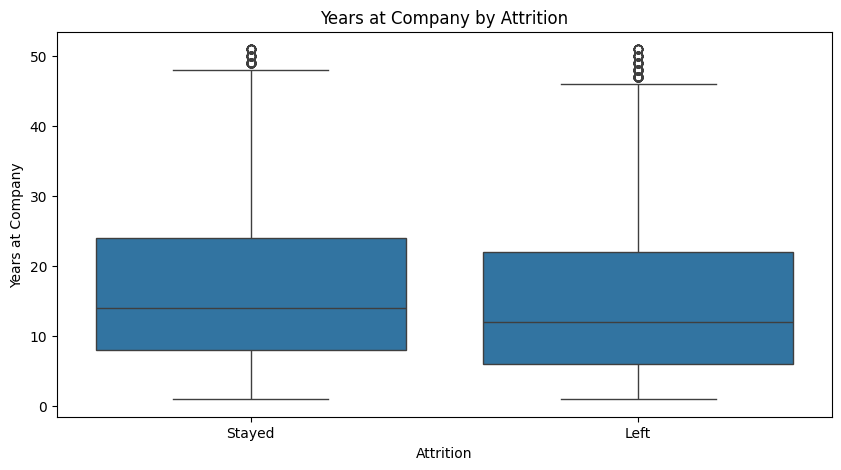

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x = 'Attrition', y = 'Years at Company')
plt.title('Years at Company by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()

## Years at Company Distribution

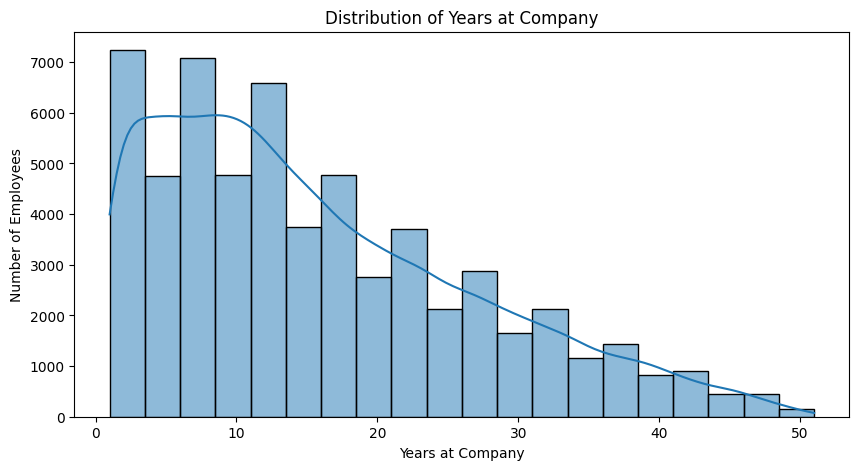

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data = df, x = 'Years at Company', bins = 20, kde = True)
plt.title('Distribution of Years at Company')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
df.groupby('Attrition')['Years at Company'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,14.987226,11.187809,1.0,6.0,12.0,22.0,51.0
Stayed,31260.0,16.448912,11.253588,1.0,8.0,14.0,24.0,51.0


### Business Insights:
- The distribution is positively skewed, with most employees having relatively fewer years at the company. Employees who stayed have a higher average tenure (16.44 years) compared with employees who left (14.99 years). The number of employees decreases as years at the company increase, with relatively few employees having more than 30 years of tenure.

## Monthly Income vs Attrition Distribution using Box Plot

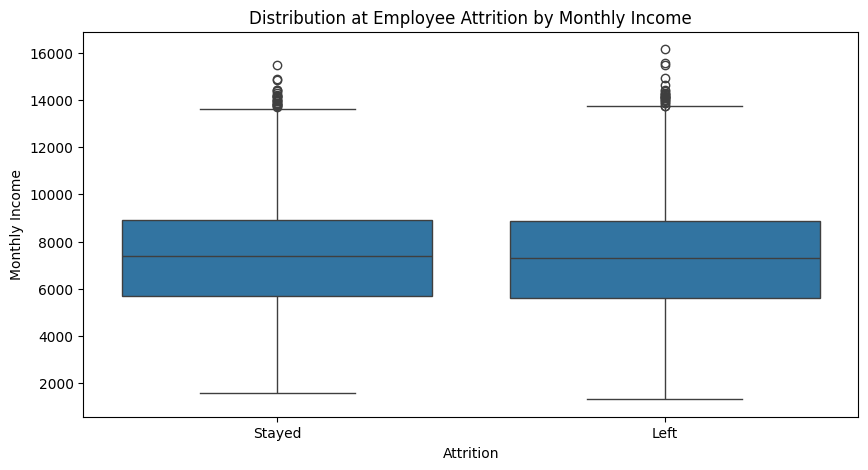

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data = df, x = 'Attrition', y = 'Monthly Income')
plt.title('Distribution at Employee Attrition by Monthly Income')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

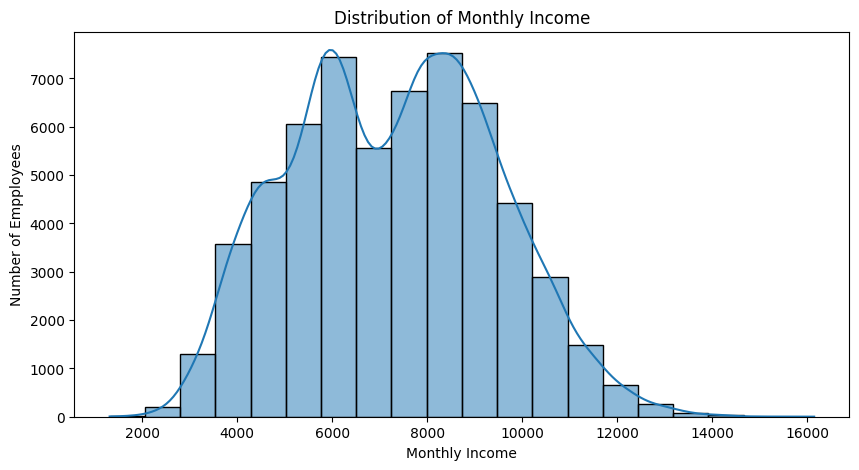

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x = 'Monthly Income', bins = 20, kde = True)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income')
plt.ylabel('Number of Empployees')
plt.show()

In [ ]:
df.groupby('Attrition')['Monthly Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,7276.689533,2162.441604,1316.0,5623.25,7321.5,8865.0,16149.0
Stayed,31260.0,7325.703359,2141.219169,1575.0,5687.00,7380.0,8894.0,15464.0


### Business Insights:
- Monthly income has a similar distribution for employees who stayed and left. The mean income is slightly higher among employees who stayed (7325.70) than those who left (7276.69), but the difference is small. Several high-income observations appear as potential outliers.

## Number of Promotions vs Attrition Distribution using Box Plot

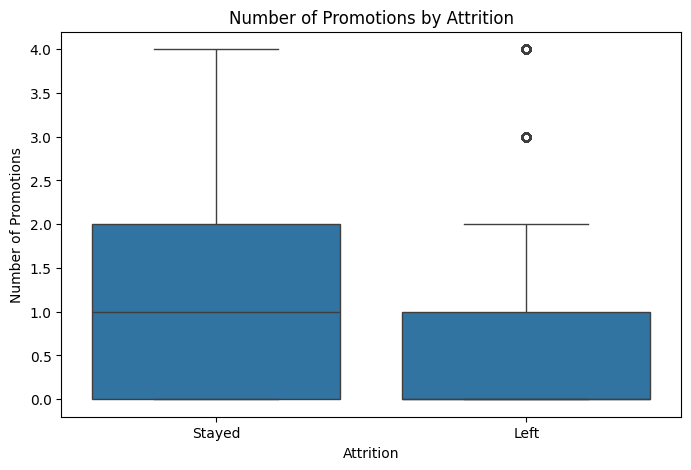

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='Number of Promotions')
plt.title('Number of Promotions by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Promotions')
plt.show()

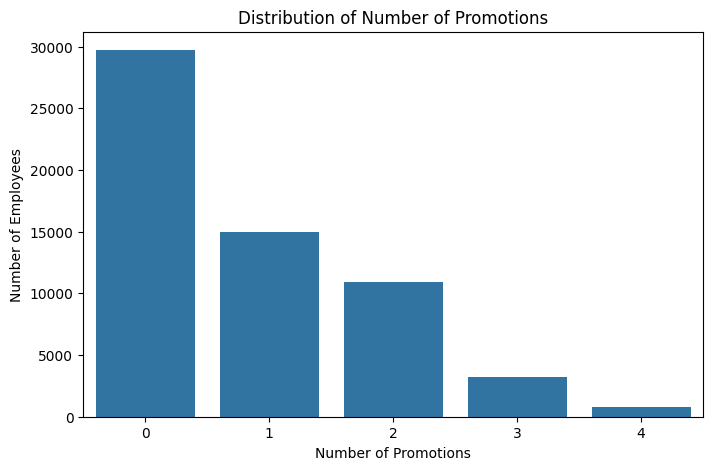

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Number of Promotions')
plt.title('Distribution of Number of Promotions')
plt.xlabel('Number of Promotions')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
df.groupby('Attrition')['Number of Promotions'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,0.748359,0.903201,0.0,0.0,0.0,1.0,4.0
Stayed,31260.0,0.908925,1.065705,0.0,0.0,1.0,2.0,4.0


### Business Insights:
- Employees who stayed generally received slightly more promotions than employees who left.

## Distance from Home vs Attrition Distribution using Box Plot

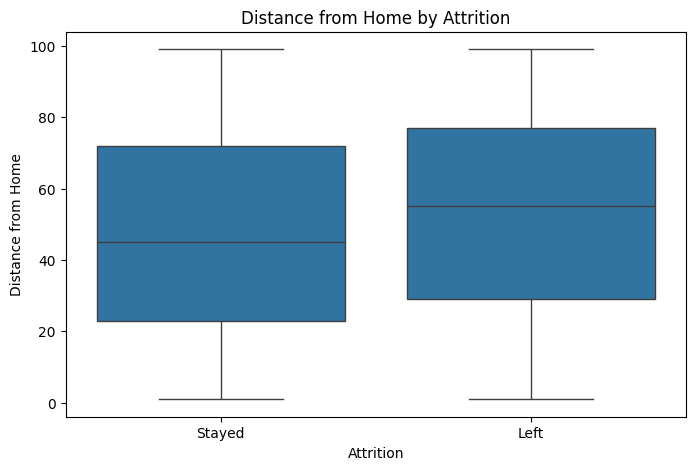

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Attrition', y='Distance from Home')
plt.title('Distance from Home by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Distance from Home')
plt.show()

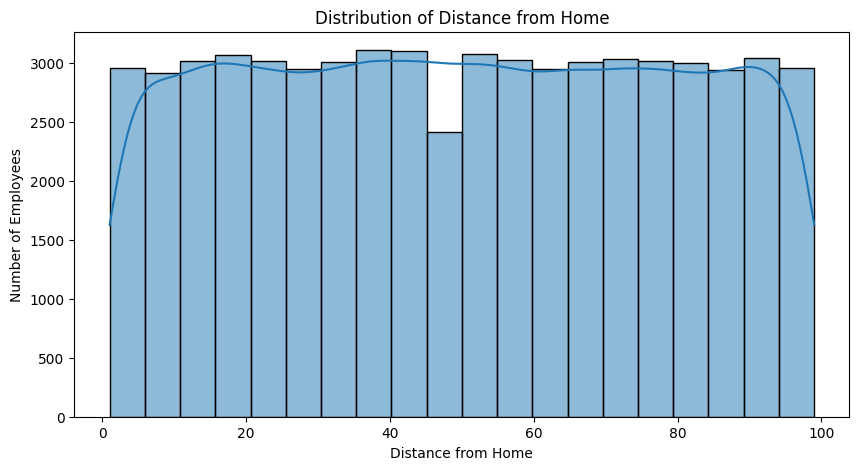

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Distance from Home', bins=20, kde=True)
plt.title('Distribution of Distance from Home')
plt.xlabel('Distance from Home')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
df.groupby('Attrition')['Distance from Home'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,52.864987,28.306901,1.0,29.0,55.0,77.0,99.0
Stayed,31260.0,47.417402,28.363110,1.0,23.0,45.0,72.0,99.0


### Business Insights:
- Employees who left the company have a higher average and median distance from home compared with employees who stayed. This indicates that employees living farther from the workplace may have a relatively higher likelihood of attrition.

## Number of Dependents vs Attrition Distribution using Box Plot

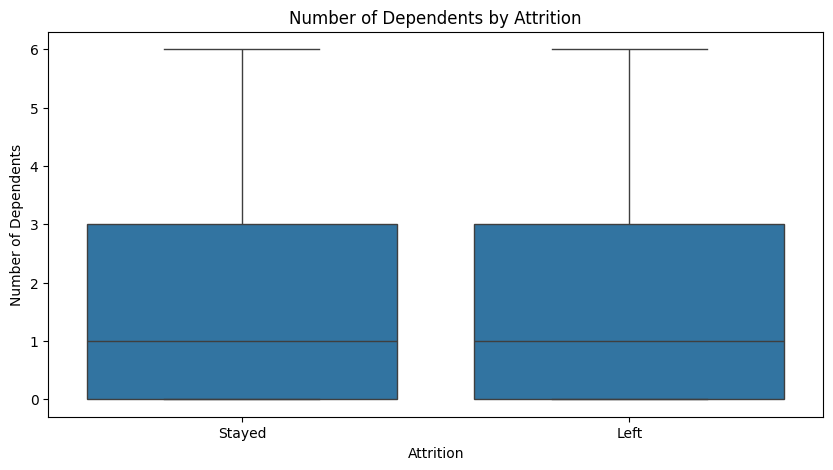

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Attrition', y='Number of Dependents')
plt.title('Number of Dependents by Attrition')
plt.xlabel('Attrition')
plt.ylabel('Number of Dependents')
plt.show()

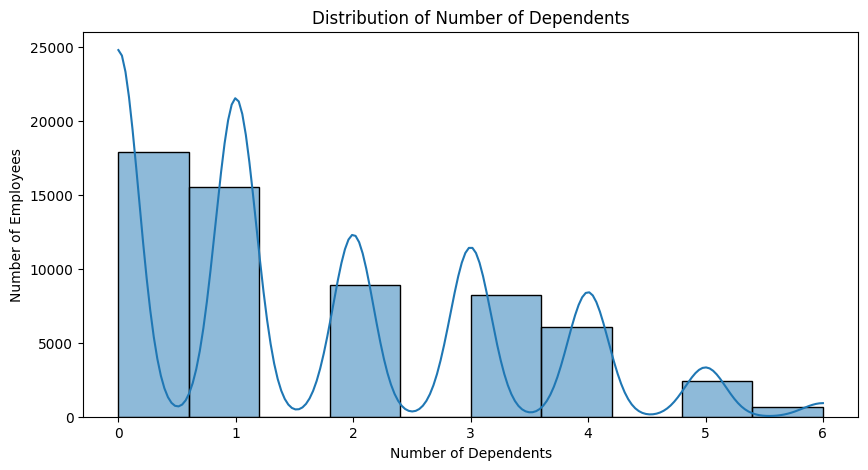

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Number of Dependents', bins=10, kde=True)
plt.title('Distribution of Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
df.groupby('Attrition')['Number of Dependents'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
Left,28338.0,1.520079,1.462414,0.0,0.0,1.0,3.0,6.0
Stayed,31260.0,1.764107,1.626999,0.0,0.0,1.0,3.0,6.0


### Business Insights:
- The median number of dependents is 1 for both employees who stayed and those who left. The average number of dependents is slightly higher for employees who stayed (1.76) compared with employees who left (1.52). Overall, the distributions are quite similar, suggesting that the number of dependents does not show a strong difference between the two attrition groups.

## Correlation Analysis for Heatmap

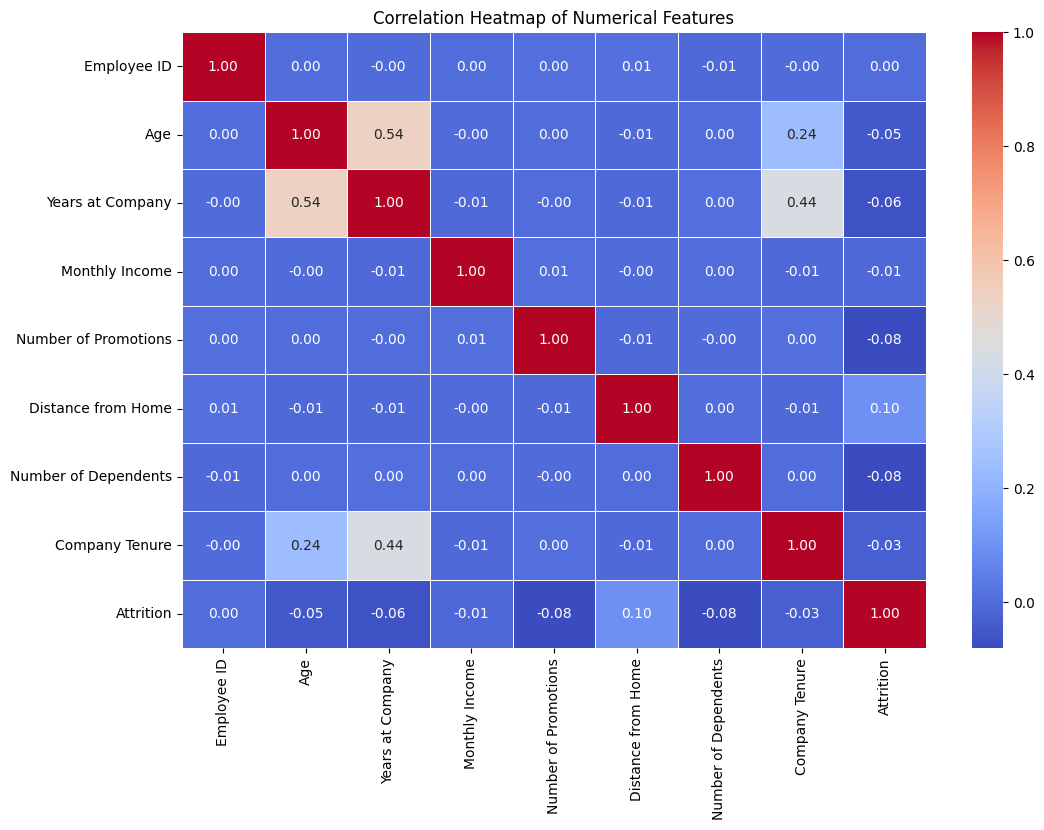

In [ ]:
# Create a copy so the original dataframe is not changed
df_corr = df.copy()

# Convert target variable into numerical values
df_corr['Attrition'] = df_corr['Attrition'].map({
    'Stayed': 0,
    'Left': 1
})

# Select numerical columns
corr = df_corr.select_dtypes(include='number').corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Outlier Detection for Numerical Features

In [ ]:
df.select_dtypes(include = ['int64', 'float64']).columns

Index(['Employee ID', 'Age', 'Years at Company', 'Monthly Income',
       'Number of Promotions', 'Distance from Home', 'Number of Dependents',
       'Company Tenure'],
      dtype='object')

In [ ]:
numerical_features = [
    'Age',
    'Years at Company',
    'Monthly Income',
    'Number of Promotions',
    'Distance from Home',
    'Number of Dependents',
    'Company Tenure'
]
print('Outlier Detection for Numerical Features')

for num in numerical_features:
  q1 = df[num].quantile(0.25)
  q3 = df[num].quantile(0.75)

  iqr = q3 - q1

  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr

  outliers = df[(df[num] < lower_bound) | df[num] > upper_bound]

  print('-' * 50)
  print('Column:', num)
  print('Q1:', q1)
  print('q3:', q3)
  print('Lower Bound:', lower_bound)
  print('Upper Bound:', upper_bound)
  print('Number of Outliers:', len(outliers))

Outlier Detection for Numerical Features
--------------------------------------------------
Column: Age
Q1: 28.0
q3: 49.0
Lower Bound: -3.5
Upper Bound: 80.5
Number of Outliers: 0
--------------------------------------------------
Column: Years at Company
Q1: 7.0
q3: 23.0
Lower Bound: -17.0
Upper Bound: 47.0
Number of Outliers: 0
--------------------------------------------------
Column: Monthly Income
Q1: 5658.0
q3: 8880.0
Lower Bound: 825.0
Upper Bound: 13713.0
Number of Outliers: 0
--------------------------------------------------
Column: Number of Promotions
Q1: 0.0
q3: 2.0
Lower Bound: -3.0
Upper Bound: 5.0
Number of Outliers: 0
--------------------------------------------------
Column: Distance from Home
Q1: 25.0
q3: 75.0
Lower Bound: -50.0
Upper Bound: 150.0
Number of Outliers: 0
--------------------------------------------------
Column: Number of Dependents
Q1: 0.0
q3: 3.0
Lower Bound: -4.5
Upper Bound: 7.5
Number of Outliers: 0
------------------------------------------------

# EDA Summary — Employee Attrition Prediction

### Dataset Overview:

- The dataset contains 59,598 employee records and 24 columns.
- The target variable is Attrition, with two classes: Stayed and Left.
- There are no missing values and no duplicate records.
- Employee ID is an identifier and is not considered a predictive feature.

### Target Distribution:

- Stayed: 52.45%
- Left: 47.55%
The target classes are reasonably balanced.

### Categorical Feature Insights:

- Work-Life Balance: Poor and Fair categories show higher attrition than Good and Excellent.
- Job Level: Entry-level employees show higher attrition than Mid and Senior employees.
- Marital Status: Single employees show higher attrition than Married and Divorced employees.
- Remote Work: Employees without remote work show higher attrition than employees with remote work.
- Company Reputation: Poor and Fair reputation categories show higher attrition than Good and Excellent.
- Overtime: Employees working overtime show somewhat higher attrition.
- Other categorical variables show relatively weaker differences.

### Numerical Feature Insights:

- Employees who left generally have slightly fewer Years at Company.
- Employees who left have a somewhat higher Distance from Home.
- Monthly Income distributions are very similar between the two groups.
- Age shows only a small difference between Stayed and Left employees.
- Employees who stayed generally have slightly more Promotions.
- Number of Dependents shows only a small difference.
- Company Tenure shows a weak relationship with attrition.

### Correlation Analysis:

- Numerical features show mostly weak linear correlations with Attrition.
- Distance from Home has the strongest positive correlation among the numerical variables (0.10).
- Years at Company and Age have a moderate positive correlation (0.54).
- Correlation alone does not determine whether a feature will be useful for a KNN model.

### Outlier Detection:

- IQR-based analysis detected 0 outliers in all seven numerical predictive features.
- Therefore, no observations need to be removed based on the IQR outlier analysis.

# Conclusion:

- The EDA indicates that several categorical variables, particularly Work-Life Balance, Job Level, Marital Status, Remote Work, and Company Reputation, show noticeable differences in attrition rates. Most numerical variables have relatively weak linear relationships with attrition. Since there are no missing values, duplicate records, or IQR-detected outliers, the dataset is suitable for proceeding to machine learning preprocessing and modeling.